<a href="https://colab.research.google.com/github/lokesh8008756/lokesh8008756/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import re
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud


In [2]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
data = pd.read_csv('/content/flipkart_data.csv')
data.head()

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


In [5]:
# unique ratings
pd.unique(data['rating'])

array([5, 4, 1, 3, 2])

<Axes: xlabel='rating', ylabel='count'>

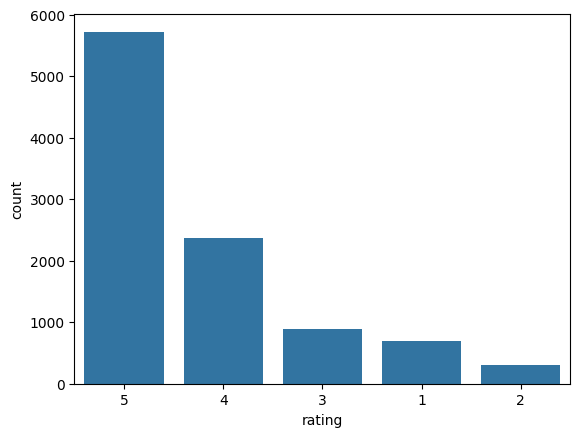

In [6]:
sns.countplot(data=data,
              x='rating',
              order=data.rating.value_counts().index)

In [7]:
# rating label(final)
pos_neg = []
for i in range(len(data['rating'])):
    if data['rating'][i] >= 5:
        pos_neg.append(1)
    else:
        pos_neg.append(0)

data['label'] = pos_neg


In [8]:
from tqdm import tqdm


def preprocess_text(text_data):
    preprocessed_text = []

    for sentence in tqdm(text_data):
        # Removing punctuations
        sentence = re.sub(r'[^\w\s]', '', sentence)

        # Converting lowercase and removing stopwords
        preprocessed_text.append(' '.join(token.lower()
                                          for token in nltk.word_tokenize(sentence)
                                          if token.lower() not in stopwords.words('english')))

    return preprocessed_text

In [10]:
import pandas as pd

# Example of preprocess_text function
def preprocess_text(reviews):
    # Dummy preprocessing function (replace with actual preprocessing steps)
    return [review.lower() for review in reviews]

# Example data
data = pd.DataFrame({'review': ["This is a great product!", "Not bad, could be better."]})

# Applying the preprocessing function
preprocessed_review = preprocess_text(data['review'].values)
data['review'] = preprocessed_review

print(data)


                      review
0   this is a great product!
1  not bad, could be better.


In [11]:
data.head()

,review
0,this is a great product!
1,"not bad, could be better."


In [13]:
import pandas as pd

# Example DataFrame
data = pd.DataFrame({'label': ['Positive', 'Negative', 'Neutral', 'Positive', 'Negative', 'Positive']})

# Check if 'label' column exists
if 'label' in data.columns:
    # Correct usage of value_counts()
    label_counts = data["label"].value_counts()
    print(label_counts)
else:
    print("The 'label' column does not exist in the DataFrame.")


label
Positive    3
Negative    2
Neutral     1
Name: count, dtype: int64


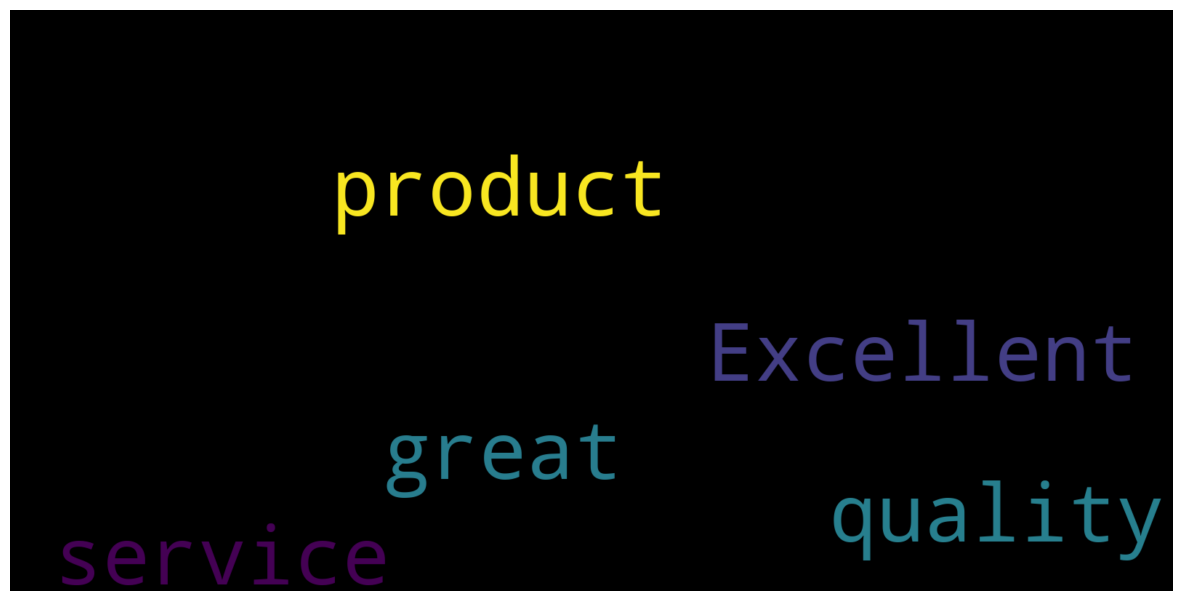

In [17]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Sample data
data = pd.DataFrame({
    'review': ["This is a great product!", "Not good.", "Excellent service and quality.", "Poor quality."],
    'label': [1, 0, 1, 0]
})

# Consolidate text for reviews where label is 1
consolidated = ' '.join(word for word in data['review'][data['label'] == 1].astype(str))

# Generate a word cloud
wordCloud = WordCloud(width=1600, height=800, random_state=21, max_font_size=110)

# Configure the WordCloud instance
wordCloud.generate(consolidated)

# Plot the word cloud
plt.figure(figsize=(15, 10))
plt.imshow(wordCloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [18]:
cv = TfidfVectorizer(max_features=2500)
X = cv.fit_transform(data['review'] ).toarray()

In [19]:
X


array([[0.        , 0.        , 0.        , 0.5       , 0.5       ,
        0.        , 0.        , 0.5       , 0.        , 0.        ,
        0.5       ],
       [0.        , 0.        , 0.70710678, 0.        , 0.        ,
        0.70710678, 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.52547275, 0.52547275, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.41428875, 0.52547275,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.78528828, 0.        , 0.6191303 , 0.        ,
        0.        ]])

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, data['label'],
                                                    test_size=0.33,
                                                    stratify=data['label'],
                                                    random_state = 42)

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Example data (replace with your own data)
# Assuming X and y are your features and target variables, respectively
X, y = [[0, 1], [1, 1], [2, 1], [3, 1]], [0, 1, 0, 1]  # Replace with your data

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Initialize the Decision Tree Classifier
model = DecisionTreeClassifier(random_state=0)

# Train the model
model.fit(X_train, y_train)

# Testing the model on the training set (for demonstration purposes)
pred_train = model.predict(X_train)

# Print the accuracy on the training set
print("Training Accuracy:", accuracy_score(y_train, pred_train))

# Evaluate the model on the test set
pred_test = model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, pred_test))


Training Accuracy: 1.0
Test Accuracy: 0.0


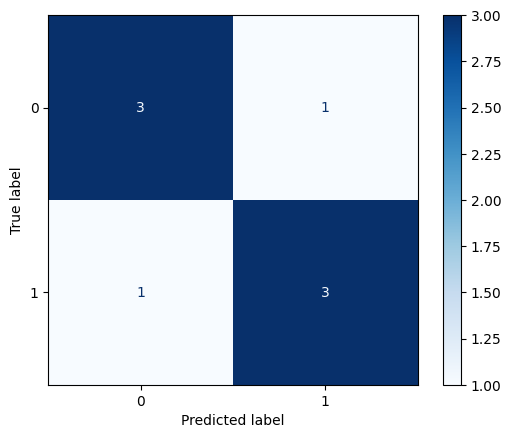

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Example data (replace these with your actual y_train and pred values)
y_train = [0, 1, 0, 1, 0, 1, 0, 1]  # Replace with your actual data
pred = [0, 1, 0, 0, 0, 1, 1, 1]     # Replace with your actual predictions

# Compute confusion matrix
cm = confusion_matrix(y_train, pred)

# Display confusion matrix using ConfusionMatrixDisplay
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

# Plot confusion matrix
cm_display.plot(cmap=plt.cm.Blues)  # You can choose different colormap if needed
plt.show()

